# Evaluación criptográfica: benchmarks de técnicas de cifrado y firmas

Este notebook mide cada algoritmo registrado en `confidential_crypto` y combina
los resultados con una tabla de puntuación de seguridad para generar un ranking por categoría.
Los mismos módulos alimentan la línea de comandos (`uv run bench run` / `uv run bench export`),
así que este notebook es para exploración; el documento de decisión final es `docs/crypto-evaluation.md`.

**¿Qué se mide?**

| Categoría | Medidas cuantitativas | Evaluación cualitativa (puntuación 0–3, con fuentes) |
|---|---|---|
| Cifradores | Velocidad de cifrado/descifrado, memoria máxima, espacio extra del ciphertext, tamaños de clave/nonce/tag, entropía y chi-cuadrado del ciphertext, detección de alteraciones | AEAD, resistencia a reuso de nonce, margen de nonce aleatorio, independencia de hardware, estandarización, madurez de librería, margen post-cuántico |
| Firmas | Tiempo de generación de claves / firmar / verificar, tamaño de clave pública y firma, determinismo | Estandarización, madurez de librería, resistencia a mal uso, resistencia a canales laterales, post-cuántico, tamaño |
| Modos de cifrado | Velocidad archivo a archivo, RSS máximo de cifrado y descifrado, espacio extra | Uso de memoria acotado, autenticación antes de liberar, detección de truncado/reordenamiento, compatible con cualquier cifrador, estabilidad de formato, simplicidad |

> `aes-256-cbc-hmac-sha256` es el ejemplo negativo a propósito (composición hecha a mano);
> el registro lo rechaza fuera de evaluación.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from bench import ciphers, export, modes, ranking, scorecard, signers
from bench.metrics import MIB
from confidential_crypto import registry

pd.set_option("display.precision", 2)
pd.set_option("display.width", 160)

print("Cifradores:", [c.name for c in registry.available_ciphers(include_unsafe=True)])
print("Firmadores:", [s.name for s in registry.available_signers(include_unsafe=True)])
print("Valores por defecto:", registry.DEFAULT_CIPHER, "/", registry.DEFAULT_SIGNER)

Ciphers : ['aes-256-gcm', 'chacha20-poly1305', 'aes-256-gcm-siv', 'xchacha20-poly1305', 'aes-256-cbc-hmac-sha256']
Signers : ['ed25519', 'ecdsa-p256', 'rsa-pss-3072', 'rsa-pss-4096', 'ml-dsa-65']
Defaults: aes-256-gcm / ed25519


## Parámetros

Los tamaños están en MiB. `ARTIFACT` puede apuntar a un modelo empaquetado real (por ejemplo,
el tar producido por el productor) para agregar una fila por cifrador con el tamaño real.

- Al menos, `REPEATS` ≥ 5

In [2]:
SIZES_MIB = [16, 64, 256]
REPEATS = 5
MESSAGE_MIB = 16          # size of the message signed in the signature benchmark
ARTIFACT = None           # e.g. Path("../artifacts/model.tar")
MEASURE_MEMORY = True     # spawns one subprocess per (cipher, size)
MODE_SIZES_MIB = [16, 64, 256]   # one-shot vs chunked vs streaming; 256 MiB ≈ the demo model
MODE_CIPHERS = ["aes-256-gcm", "chacha20-poly1305"]
CHUNK_MIB = 1

## 1. Cifradores — mediciones

In [3]:
cipher_results = ciphers.run(
    [int(s * MIB) for s in SIZES_MIB],
    repeats=REPEATS,
    artifact_path=ARTIFACT,
    measure_memory=MEASURE_MEMORY,
)
view = cipher_results.assign(size_mib=cipher_results["size_bytes"] / MIB).drop(columns="size_bytes")
view[["cipher", "size_mib", "encrypt_mib_s", "decrypt_mib_s", "peak_rss_mib",
      "overhead_bytes", "nonce_bytes", "tag_bytes", "tamper_detected"]]

,cipher,size_mib,encrypt_mib_s,decrypt_mib_s,peak_rss_mib,overhead_bytes,nonce_bytes,tag_bytes,tamper_detected
0,aes-256-gcm,16.0,1231.52,4920.19,48.01,35,12,16,True
1,chacha20-poly1305,16.0,924.94,1989.40,48.01,35,12,16,True
2,aes-256-gcm-siv,16.0,486.83,690.41,48.01,35,12,16,True
3,xchacha20-poly1305,16.0,641.24,1238.86,79.95,47,24,16,True
4,aes-256-cbc-hmac-sha256,16.0,428.91,588.46,96.00,71,16,32,True
5,aes-256-gcm,64.0,1176.99,2033.55,192.02,35,12,16,True
6,chacha20-poly1305,64.0,878.12,1331.70,192.02,35,12,16,True
7,aes-256-gcm-siv,64.0,496.22,607.24,192.02,35,12,16,True
8,xchacha20-poly1305,64.0,625.74,625.43,319.70,47,24,16,True
9,aes-256-cbc-hmac-sha256,64.0,337.63,470.02,319.63,71,16,32,True


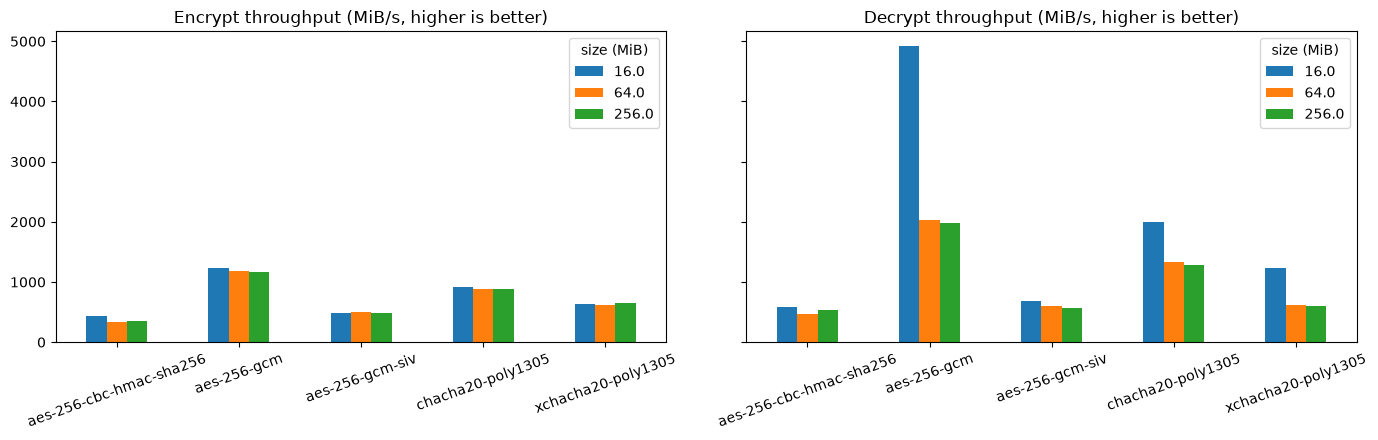

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, column, title in zip(axes, ["encrypt_mib_s", "decrypt_mib_s"], ["Cifrado", "Descifrado"]):
    pivot = view.pivot(index="cipher", columns="size_mib", values=column)
    pivot.plot.bar(ax=ax, rot=20)
    ax.set_title(f"{title} (MiB/s, mayor es mejor)")
    ax.set_xlabel("")
    ax.legend(title="tamaño (MiB)")
plt.tight_layout()

### Estadísticas del ciphertext — una verificación, no un criterio de ranking

Un cifrador correcto produce bytes indistinguibles de datos aleatorios: entropía ≈ 8.0 bits/byte y
un valor de chi-cuadrado cercano a 255 (sus grados de libertad; valores entre 200–320 son
normales para estos tamaños de muestra). Estos números **no sirven para comparar** cifradores entre sí;
solo detectan errores graves de implementación (un patrón tipo ECB, un nonce constante,
o texto plano filtrándose). Por eso no se usan en el ranking de abajo.

In [5]:
view[["cipher", "size_mib", "entropy_bits_per_byte", "chi_square"]].pivot(
    index="cipher", columns="size_mib"
)

entropy_bits_per_byte             chi_square                
size_mib                                16.0  64.0  256.0      16.0    64.0    256.0
cipher                                                                              
aes-256-cbc-hmac-sha256                   8.0   8.0   8.0     274.96  243.20  285.23
aes-256-gcm                               8.0   8.0   8.0     251.75  249.37  251.14
aes-256-gcm-siv                           8.0   8.0   8.0     221.58  238.66  247.98
chacha20-poly1305                         8.0   8.0   8.0     274.80  251.39  261.14
xchacha20-poly1305                        8.0   8.0   8.0     215.89  265.20  254.76

### Memoria máxima

La medición ejecuta cada (cifrador, tamaño) en un intérprete nuevo y reporta el crecimiento de RSS
respecto al intérprete base: texto plano + ciphertext + copia descifrada. Un diseño de una sola pasada
en memoria necesita aproximadamente 3–4× el tamaño del artefacto; este es el límite que un formato
por fragmentos (documentado como trabajo futuro) eliminaría.

In [6]:
view.pivot(index="cipher", columns="size_mib", values="peak_rss_mib")

size_mib,16.0,64.0,256.0
cipher,,,
aes-256-cbc-hmac-sha256,96.00,319.63,1279.64
aes-256-gcm,48.01,192.02,768.02
aes-256-gcm-siv,48.01,192.02,768.02
chacha20-poly1305,48.01,192.02,768.02
xchacha20-poly1305,79.95,319.70,1279.45


## 2. Cifradores — tabla de seguridad

In [7]:
cipher_card = scorecard.cipher_scorecard()
cipher_criteria, signer_criteria = scorecard.criteria()
display(Markdown("\n".join(f"- **{k}**: {v}" for k, v in cipher_criteria.items())))
cipher_card.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=3, subset=list(cipher_criteria))

- **aead**: Native authenticated encryption primitive (not a hand-rolled composition)
- **nonce_misuse_resistance**: Consequence of accidentally reusing a nonce with the same key
- **random_nonce_headroom**: Messages per key before random-nonce collision becomes a concern
- **hardware_independence**: Performance and constant-time behaviour without AES-NI/PCLMUL
- **standardisation**: RFC / NIST / FIPS status
- **library_maturity**: Backend maturity and audit history
- **post_quantum**: Margin against Grover (256-bit keys keep 128-bit PQ security)

,aead,nonce_misuse_resistance,random_nonce_headroom,hardware_independence,standardisation,library_maturity,post_quantum,score
name,,,,,,,,
aes-256-gcm,3,0,2,1,3,3,3,15
chacha20-poly1305,3,0,2,3,2,3,3,16
xchacha20-poly1305,3,1,3,3,1,2,3,16
aes-256-gcm-siv,3,3,3,1,2,2,3,17
aes-256-cbc-hmac-sha256,0,1,2,1,1,0,3,8


In [8]:
cipher_notes, signer_notes = scorecard.notes()
display(Markdown("\n\n".join(
    f"**{name}** — {entry['notes']}\n\n" + "\n".join(f"  - {s}" for s in entry["sources"])
    for name, entry in cipher_notes.items()
)))

**aes-256-gcm** — Nonce reuse breaks confidentiality and authentication (GHASH key recovery). 96-bit random nonces: NIST SP 800-38D limits to 2^32 invocations per key. Needs AES-NI + PCLMULQDQ for speed and constant time; software AES is slow and table-based implementations leak timing.

  - NIST SP 800-38D (GCM), section 8.3 random IV limit
  - RFC 5116 (AEAD interface)
  - Joux, 'Authentication failures in NIST version of GCM' (nonce reuse)

**chacha20-poly1305** — Same 96-bit nonce and same catastrophic reuse as GCM. Constant-time in pure software; the TLS 1.3 alternative to AES-GCM. Not on the FIPS 140-3 approved list.

  - RFC 8439 (ChaCha20 and Poly1305 for IETF protocols)
  - RFC 8446 (TLS 1.3 cipher suites)

**xchacha20-poly1305** — 192-bit nonce makes random-nonce collisions negligible (~2^80 messages), so the operational nonce-management risk disappears; deliberate reuse is still fatal. Specified only in an expired IRTF draft; de facto standard through libsodium.

  - draft-irtf-cfrg-xchacha-03 (expired)
  - libsodium documentation, AEAD constructions

**aes-256-gcm-siv** — Nonce reuse only reveals whether two plaintexts are equal. Requires two passes over the data, so it is slower than GCM. Available in OpenSSL 3.2+; less deployed.

  - RFC 8452 (AES-GCM-SIV)
  - Gueron, Langley, Lindell, 'AES-GCM-SIV: Specification and Analysis'

**aes-256-cbc-hmac-sha256** — Evaluation-only negative example. Encrypt-then-MAC composition written by hand: correctness depends on key separation, MAC coverage of nonce and AAD, constant-time comparison and padding handling. Every historic CBC padding-oracle bug came from this class of composition. Two passes and two primitives.

  - Bellare, Namprempre, 'Authenticated Encryption: Relations among notions'
  - Vaudenay, 'Security flaws induced by CBC padding' (padding oracles)

## 3. Cifradores — ranking ponderado

Los pesos son explícitos. La seguridad domina a propósito: el artefacto se cifra una vez y se
descifra una vez por despliegue, así que una diferencia de 2× en velocidad cuesta unos segundos,
mientras que una propiedad de seguridad cuesta el diseño completo. Cambia los pesos y vuelve a
ejecutar la celda para ver cuán robusto es el ganador.

In [9]:
CIPHER_WEIGHTS = dict(ranking.CIPHER_WEIGHTS)   # e.g. {"encrypt_mib_s": 1, "decrypt_mib_s": 1, "peak_rss_mib": 0.5, "security_score": 3}
cipher_rank = ranking.rank(cipher_results, cipher_card, CIPHER_WEIGHTS, key="cipher")
cipher_rank

,encrypt_mib_s,decrypt_mib_s,peak_rss_mib,security_score,total,production_safe
cipher,,,,,,
aes-256-gcm,1.00,1.00,0.50,2.33,4.83,True
chacha20-poly1305,0.64,0.41,0.50,2.67,4.22,True
aes-256-gcm-siv,0.14,0.04,0.50,3.00,3.68,True
xchacha20-poly1305,0.33,0.12,0.01,2.67,3.12,True
aes-256-cbc-hmac-sha256,0.00,0.00,0.00,0.00,0.00,False


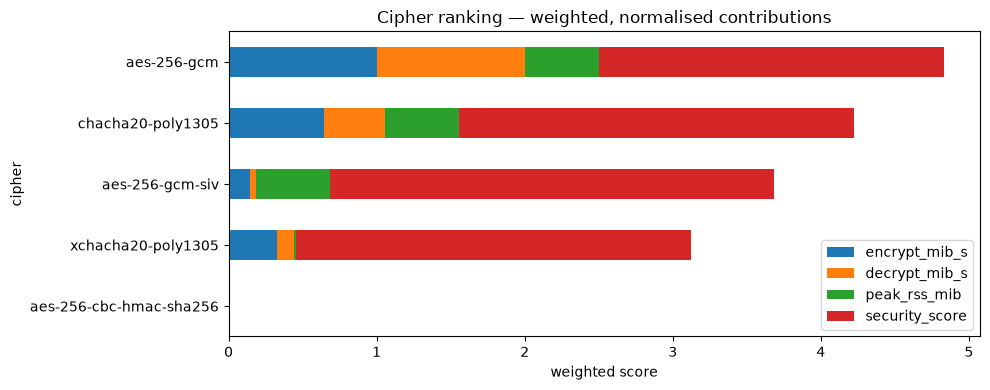

In [10]:
ax = cipher_rank.drop(columns=["total", "production_safe"]).plot.barh(stacked=True, figsize=(10, 4))
ax.invert_yaxis()
ax.set_title("Ranking de cifradores — contribuciones ponderadas y normalizadas")
ax.set_xlabel("puntuación ponderada")
plt.tight_layout()

## 4. Esquemas de firma — mediciones

In [11]:
signer_results = signers.run(int(MESSAGE_MIB * MIB), repeats=REPEATS)
signer_results[["scheme", "keygen_ms", "sign_ms", "verify_ms",
                "public_key_pem_bytes", "signature_bytes", "deterministic"]]

,scheme,keygen_ms,sign_ms,verify_ms,public_key_pem_bytes,signature_bytes,deterministic
0,ed25519,0.03,36.73,19.52,113,64,True
1,ecdsa-p256,0.02,8.07,8.49,178,72,False
2,rsa-pss-3072,320.57,96.64,8.60,625,384,False
3,rsa-pss-4096,848.29,210.97,8.35,800,512,False
4,ml-dsa-65,0.14,31.53,30.58,2726,3309,False


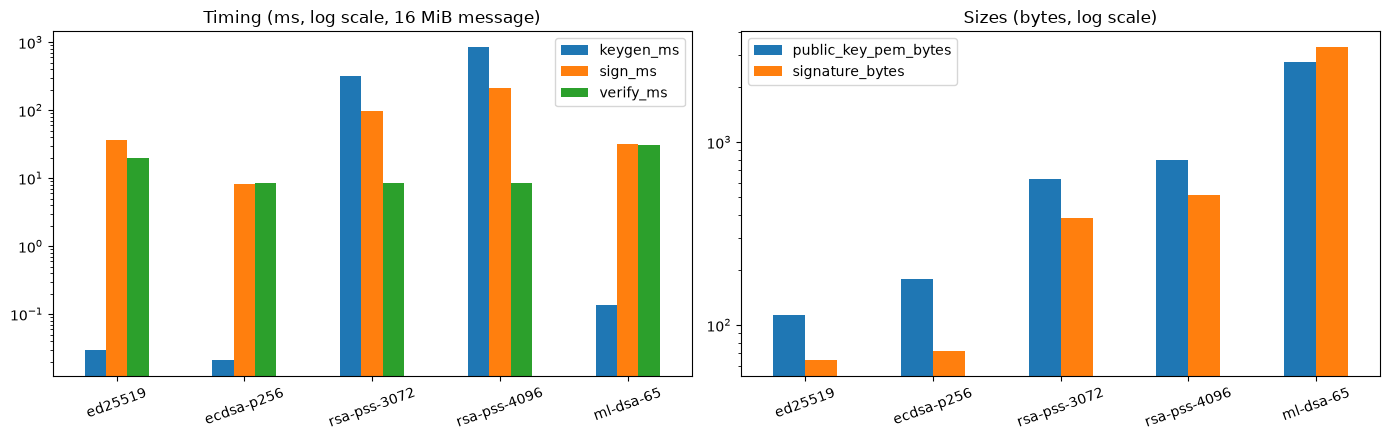

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
timing = signer_results.set_index("scheme")[["keygen_ms", "sign_ms", "verify_ms"]]
timing.plot.bar(ax=axes[0], rot=20, logy=True)
axes[0].set_title(f"Tiempos (ms, escala log, mensaje de {MESSAGE_MIB} MiB)")
axes[0].set_xlabel("")
sizes = signer_results.set_index("scheme")[["public_key_pem_bytes", "signature_bytes"]]
sizes.plot.bar(ax=axes[1], rot=20, logy=True)
axes[1].set_title("Tamaños (bytes, escala log)")
axes[1].set_xlabel("")
plt.tight_layout()

## 5. Esquemas de firma — tabla de seguridad y ranking

In [13]:
signer_card = scorecard.signer_scorecard()
display(Markdown("\n".join(f"- **{k}**: {v}" for k, v in signer_criteria.items())))
signer_card.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=3, subset=list(signer_criteria))

- **standardisation**: RFC / NIST / FIPS status
- **library_maturity**: Backend maturity and deployment history
- **misuse_resistance**: Robustness against implementation and randomness failures
- **side_channel_resistance**: Constant-time design of the reference algorithm
- **post_quantum**: Security against a large quantum computer
- **key_and_signature_size**: Compactness of public key and signature

,standardisation,library_maturity,misuse_resistance,side_channel_resistance,post_quantum,key_and_signature_size,score
name,,,,,,,
ed25519,3,3,3,3,0,3,15
ecdsa-p256,3,3,1,2,0,3,12
rsa-pss-3072,3,3,2,2,0,1,11
rsa-pss-4096,3,3,2,2,0,0,10
ml-dsa-65,3,1,2,2,3,0,11


In [14]:
display(Markdown("\n\n".join(
    f"**{name}** — {entry['notes']}\n\n" + "\n".join(f"  - {s}" for s in entry["sources"])
    for name, entry in signer_notes.items()
)))

**ed25519** — Deterministic signatures: no per-signature randomness to get wrong. Designed for constant-time implementation. 32-byte keys, 64-byte signatures.

  - RFC 8032 (EdDSA)
  - FIPS 186-5 (approved since 2023)
  - Bernstein et al., 'High-speed high-security signatures'

**ecdsa-p256** — Requires a fresh, secret, uniformly random nonce per signature; reusing or biasing it leaks the private key (Sony PS3, Bitcoin wallet incidents). RFC 6979 deterministic nonces mitigate this but are not used by every backend.

  - FIPS 186-5 (ECDSA)
  - RFC 6979 (deterministic ECDSA)
  - fail0verflow, 'Console Hacking 2010' (PS3 nonce reuse)

**rsa-pss-3072** — Probabilistic padding with a security proof. Large keys and signatures, slow key generation and signing; verification is fast. 3072 bits is the NIST 128-bit level.

  - RFC 8017 (PKCS #1 v2.2, RSASSA-PSS)
  - NIST SP 800-57 Part 1 (key size equivalences)

**rsa-pss-4096** — Same properties as 3072 with more margin and proportionally slower operations.

  - RFC 8017 (PKCS #1 v2.2, RSASSA-PSS)

**ml-dsa-65** — NIST post-quantum standard (Dilithium). ~2 KB public keys and ~3.3 KB signatures. Hedged (randomised) signing by default. Implementations are new; few audits.

  - FIPS 204 (ML-DSA, August 2024)
  - CNSA 2.0 (NSA guidance recommending ML-DSA)

In [15]:
SIGNER_WEIGHTS = dict(ranking.SIGNER_WEIGHTS)
signer_rank = ranking.rank(signer_results, signer_card, SIGNER_WEIGHTS, key="scheme")
signer_rank

,sign_ms,verify_ms,signature_bytes,security_score,total,production_safe
scheme,,,,,,
ed25519,0.43,0.50,0.50,3.0,4.43,True
ecdsa-p256,0.50,0.99,0.50,1.2,3.19,True
rsa-pss-3072,0.28,0.99,0.45,0.6,2.32,True
rsa-pss-4096,0.00,1.00,0.43,0.0,1.43,True
ml-dsa-65,0.44,0.00,0.00,0.6,1.04,True


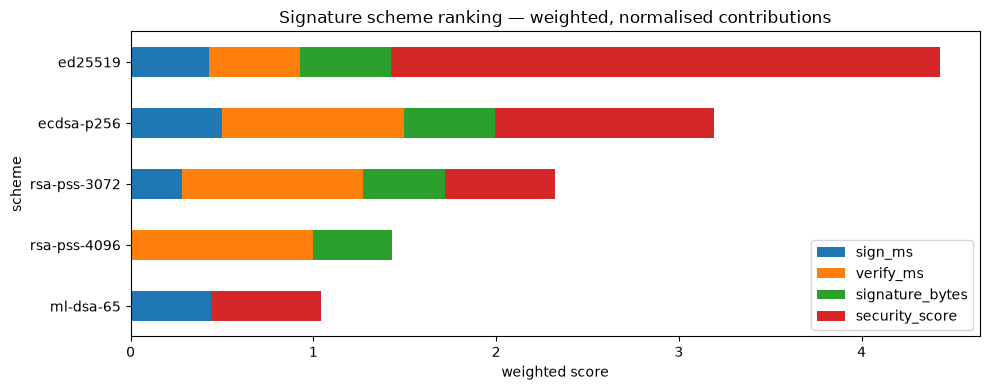

In [16]:
ax = signer_rank.drop(columns=["total", "production_safe"]).plot.barh(stacked=True, figsize=(10, 4))
ax.invert_yaxis()
ax.set_title("Ranking de esquemas de firma — contribuciones ponderadas y normalizadas")
ax.set_xlabel("puntuación ponderada")
plt.tight_layout()

## 6. Modos de cifrado — de una sola pasada vs por fragmentos vs flujo continuo

Tres formas de aplicar el mismo cifrador AEAD a un archivo:

| Modo | Formato | Memoria | ¿El texto plano se libera solo después de autenticar? |
|---|---|---|---|
| **one-shot** | v1 | ~2× el artefacto (buffers de entrada y salida) | sí — un solo tag para todo |
| **chunked** | v2 (STREAM: nonce = prefijo ‖ contador ‖ flag-final, el encabezado va en el AAD de cada fragmento) | O(fragmento) | sí — por fragmento; el contador y el flag final detectan truncado y reordenamiento |
| **streaming-gcm** *(solo evaluación, AES-GCM)* | bytes v1, API incremental | O(fragmento) | **no** — el texto plano se emite antes de verificar el tag final |

Los tres operan archivo a archivo; la memoria es el punto máximo de RSS de un proceso nuevo por operación.

In [17]:
mode_results = modes.run(
    [int(s * MIB) for s in MODE_SIZES_MIB],
    ciphers=MODE_CIPHERS,
    chunk=int(CHUNK_MIB * MIB),
    repeats=max(1, REPEATS // 2),
    artifact_path=ARTIFACT,
    measure_memory=MEASURE_MEMORY,
)
mode_view = mode_results.assign(size_mib=mode_results["size_bytes"] / MIB)
mode_view[["mode", "cipher", "size_mib", "encrypt_mib_s", "decrypt_mib_s",
           "peak_rss_encrypt_mib", "peak_rss_decrypt_mib", "overhead_bytes",
           "plaintext_released_before_auth"]]

,mode,cipher,size_mib,encrypt_mib_s,decrypt_mib_s,peak_rss_encrypt_mib,peak_rss_decrypt_mib,overhead_bytes,plaintext_released_before_auth
0,one-shot,aes-256-gcm,16.0,677.36,687.09,31.55,31.65,35,False
1,chunked,aes-256-gcm,16.0,962.60,1158.06,2.66,3.58,274,False
2,streaming-gcm,aes-256-gcm,16.0,852.62,1200.01,1.61,1.24,35,True
3,one-shot,chacha20-poly1305,16.0,565.75,577.89,31.15,31.39,35,False
4,chunked,chacha20-poly1305,16.0,770.40,790.18,2.63,3.40,274,False
5,one-shot,aes-256-gcm,64.0,628.42,661.20,127.64,127.59,35,False
6,chunked,aes-256-gcm,64.0,1117.16,861.44,2.61,3.30,1042,False
7,streaming-gcm,aes-256-gcm,64.0,1113.13,1283.28,1.52,1.36,35,True
8,one-shot,chacha20-poly1305,64.0,537.24,525.93,127.14,127.54,35,False
9,chunked,chacha20-poly1305,64.0,874.36,869.19,2.43,3.68,1042,False


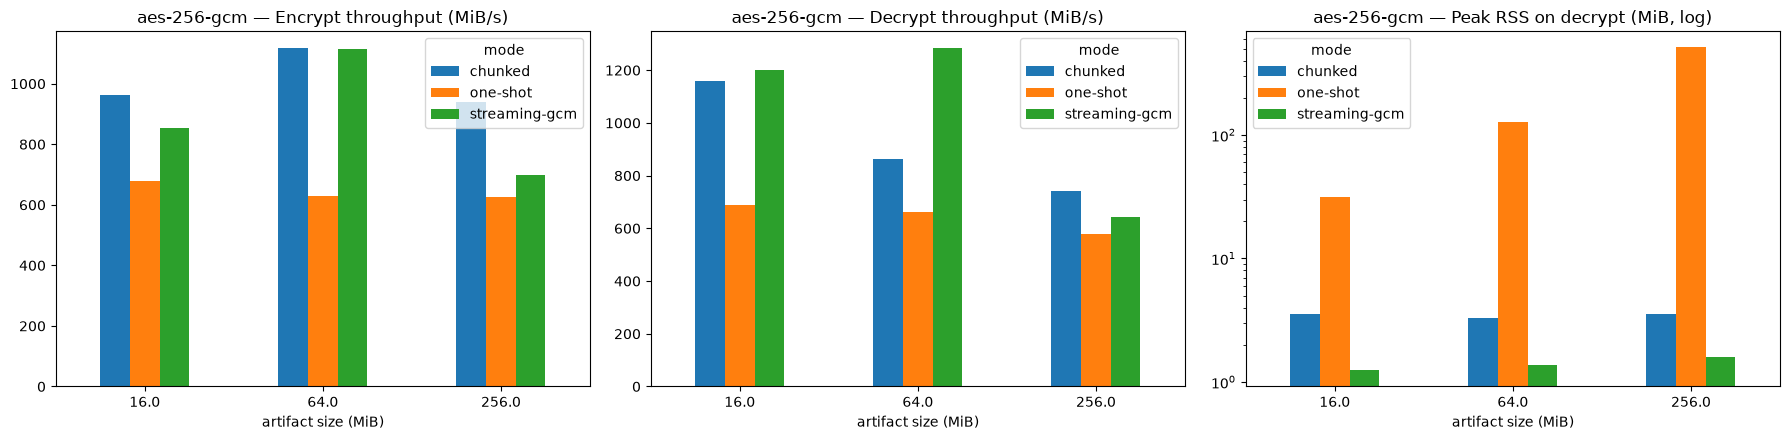

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
gcm = mode_view[mode_view["cipher"] == "aes-256-gcm"]
for ax, column, title in zip(
    axes,
    ["encrypt_mib_s", "decrypt_mib_s", "peak_rss_decrypt_mib"],
    ["Velocidad de cifrado (MiB/s)", "Velocidad de descifrado (MiB/s)", "RSS máximo al descifrar (MiB, log)"],
):
    gcm.pivot(index="size_mib", columns="mode", values=column).plot.bar(ax=ax, rot=0)
    ax.set_title(f"aes-256-gcm — {title}")
    ax.set_xlabel("tamaño del artefacto (MiB)")
axes[2].set_yscale("log")
plt.tight_layout()

### Tabla de puntuación de modos

Propiedades de seguridad e ingeniería que los números no muestran. `streaming-gcm` obtiene 0 en
*autenticación antes de liberar*: esa sola propiedad es descalificante para un consumidor que carga
el modelo directamente desde la salida descifrada.

In [19]:
mode_card = scorecard.mode_scorecard()
display(Markdown("\n".join(f"- **{k}**: {v}" for k, v in scorecard.mode_criteria().items())))
mode_card.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=3, subset=list(scorecard.mode_criteria()))

- **memory_bound**: Peak memory independent of artifact size
- **auth_before_release**: No plaintext leaves the decryptor before it is authenticated
- **truncation_detection**: Dropping trailing data is detected
- **reorder_detection**: Moving or swapping ciphertext segments is detected
- **cipher_agnostic**: Works with any AEAD in the registry
- **format_stability**: Wire format shared with the baseline (no version bump)
- **implementation_simplicity**: Amount of logic that can be wrong

,memory_bound,auth_before_release,truncation_detection,reorder_detection,cipher_agnostic,format_stability,implementation_simplicity,score
name,,,,,,,,
one-shot,0,3,3,3,3,3,3,18
chunked,3,3,3,3,3,1,1,17
streaming-gcm,3,0,3,3,0,3,2,14


In [20]:
display(Markdown("\n\n".join(
    f"**{name}** — {entry['notes']}\n\n" + "\n".join(f"  - {s}" for s in entry["sources"])
    for name, entry in scorecard.mode_notes().items()
)))

**one-shot** — One AEAD call over the whole artifact: the simplest possible code and the strongest atomic guarantee (nothing is released unless everything verifies). Costs ~2x the artifact in RAM on each side (input plus output buffer); fine for a ~270 MB model, not for multi-GB LLM weights.

  - RFC 5116 section 2 (AEAD as an all-or-nothing interface)

**chunked** — STREAM construction (Hoang, Reyhanitabar, Rogaway, Vizár 2015): per-chunk AEAD with nonce = prefix || counter || last-flag and the header in every chunk's AAD. Memory is O(chunk); each chunk is authenticated before its plaintext is written; counter and last flag catch reordering and truncation at chunk boundaries. Requires a format version bump, one tag per chunk, and more code to get right (nonce derivation, last-chunk handling, short-read logic).

  - Hoang, Reyhanitabar, Rogaway, Vizár, 'Online Authenticated-Encryption and its Nonce-Reuse Misuse-Resistance' (CRYPTO 2015), STREAM
  - age file format specification (chunked STREAM with ChaCha20-Poly1305)
  - Google Tink streaming AEAD design

**streaming-gcm** — Incremental AES-GCM producing byte-identical version-1 artifacts. Memory O(chunk) with no format change, but decryption emits plaintext before the single final tag is checked: the consumer must quarantine the output and discard it on failure, and any mistake there means unauthenticated data is used. Only AES-GCM offers this incremental API in `cryptography`; AES-GCM-SIV cannot stream at all (two passes).

  - Bellare, Namprempre; 'release of unverified plaintext' (Andreeva et al., ASIACRYPT 2014)
  - cryptography.hazmat.primitives.ciphers.modes.GCM documentation (finalize_with_tag)

### Cómo leer los resultados de los modos

- **Eficiencia**: chunked y streaming-gcm mantienen la memoria plana en unos pocos MiB sin importar el tamaño; one-shot
  necesita ~2× el artefacto. Archivo a archivo, chunked **no** es más lento que one-shot — los buffers monobloque grandes
  cuestan fallos de página que el bucle de fragmentos de 1 MiB evita.
- **Seguridad**: one-shot y chunked autentican antes de liberar texto plano y ambos detectan truncado y
  reordenamiento. streaming-gcm cambia esa garantía por estabilidad de formato, que es el cambio equivocado para este sistema.
- **Costo de chunked**: un cambio de versión de formato, un tag de 16 bytes por fragmento (0.0015 % con fragmentos de 1 MiB),
  y lógica STREAM que debe estar correcta (derivación del nonce, flag de último fragmento, lectura corta) — todo cubierto por
  pruebas negativas en `packages/confidential-crypto/tests/test_chunked.py`.

## 7. Decisión

Los valores por defecto del registro deben ser defendibles frente a esta tabla. Si el candidato mejor
clasificado y apto para producción difiere de `DEFAULT_CIPHER` / `DEFAULT_SIGNER`, o cambias el
valor por defecto o escribes la justificación en el ADR (la exportación lo marca como
**Desviación** automáticamente).

Para el **modo** de cifrado, la decisión no es un valor por defecto del registro sino una configuración
del productor: `one-shot` por simplicidad a escala de demo, `chunked` cuando la memoria no debe
crecer con el modelo. El consumidor decide según el byte de versión autenticado, así que ambos pueden coexistir.

In [21]:
best_cipher = cipher_rank[cipher_rank["production_safe"]].index[0]
best_signer = signer_rank[signer_rank["production_safe"]].index[0]
print(f"Mejor cifrador: {best_cipher:20s} valor por defecto: {registry.DEFAULT_CIPHER}")
print(f"Mejor firmador: {best_signer:20s} valor por defecto: {registry.DEFAULT_SIGNER}")

top cipher : aes-256-gcm              default: aes-256-gcm
top signer : ed25519                  default: ed25519


## 8. Exportar el registro de decisión

Escribe `docs/crypto-evaluation.md` a partir de los DataFrames anteriores (mismo renderizador que
`uv run bench export`). Publica el resultado junto con cualquier cambio en los valores por defecto del registro.

In [22]:
from pathlib import Path

target = Path("../../docs/crypto-evaluation.md")
export.write(cipher_results, signer_results, mode_results, target)
print("Registro escrito en", target.resolve())

wrote /opt/confidential-ml-model-delivery/docs/crypto-evaluation.md
